### Data Exploration

##### Importing all the required libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns

##### Loading the csv file into a dataframe

In [ ]:
df = pd.read_csv('../Data Files/Raw Files Prototype/credit_card_frauds.csv')
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[()\-\/]", "", regex=True)
)

##### Checkng the distribution of the data

Text(0.5, 1.0, 'Distribution of Fraudulent vs Non-Fraudulent Transactions')

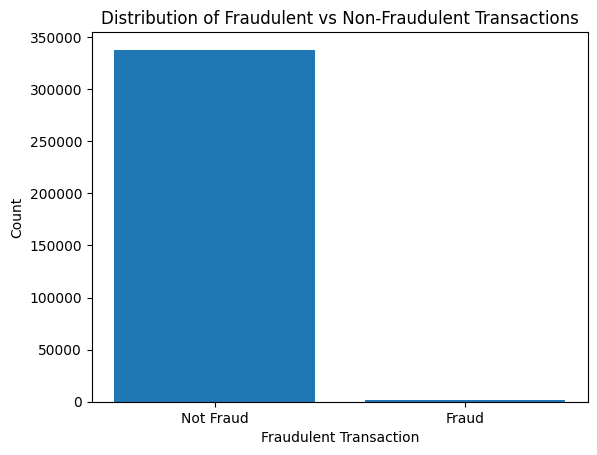

In [4]:
plt.bar(df['is_fraud'].value_counts().index,
            df['is_fraud'].value_counts().values)
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.xlabel('Fraudulent Transaction')
plt.ylabel('Count')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

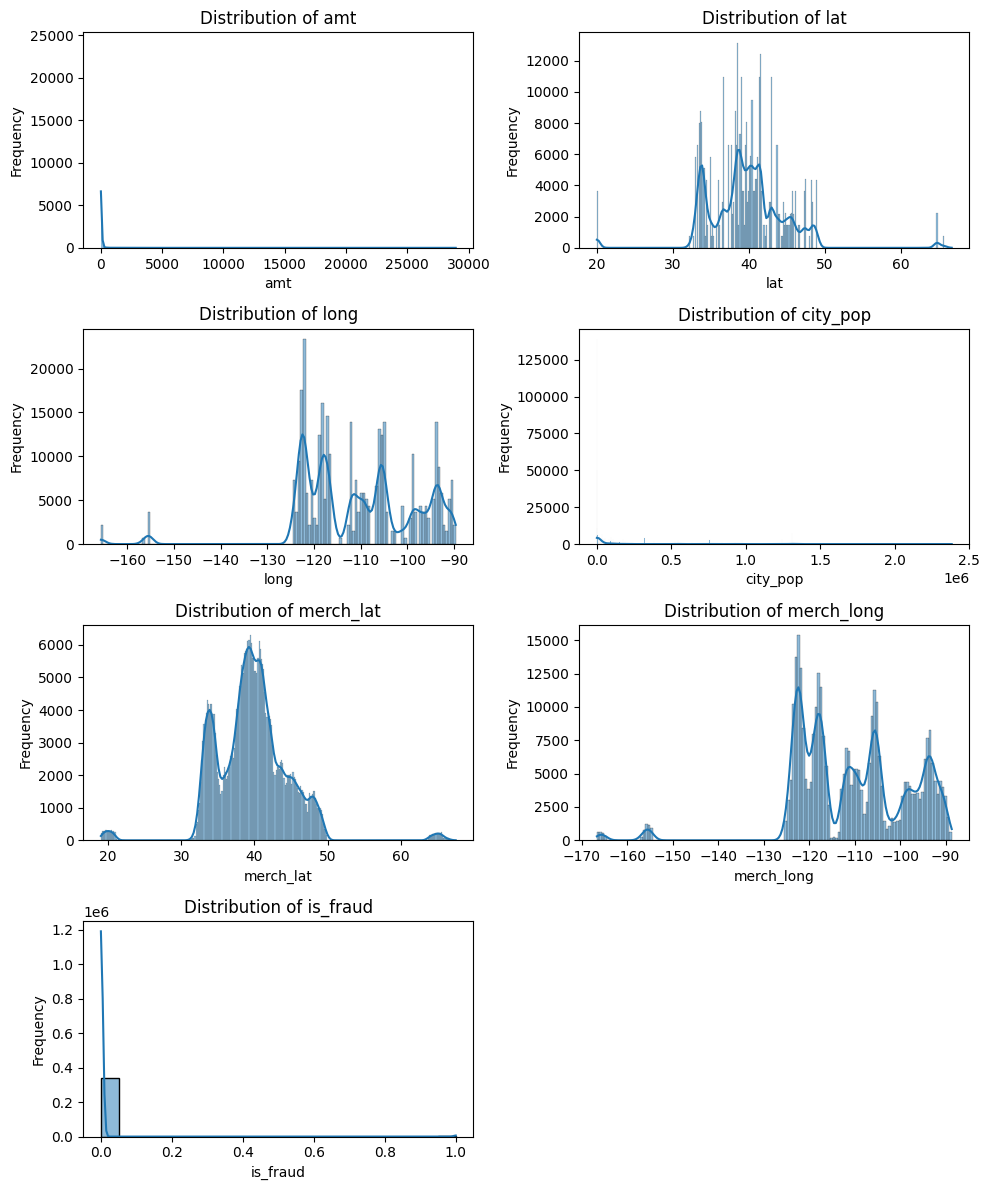

In [6]:
numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()

fig, axes = plt.subplots(nrows = len(numeric_cols) // 2 + 1, ncols = 2, figsize = (10, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax = axes[i], kde = True)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

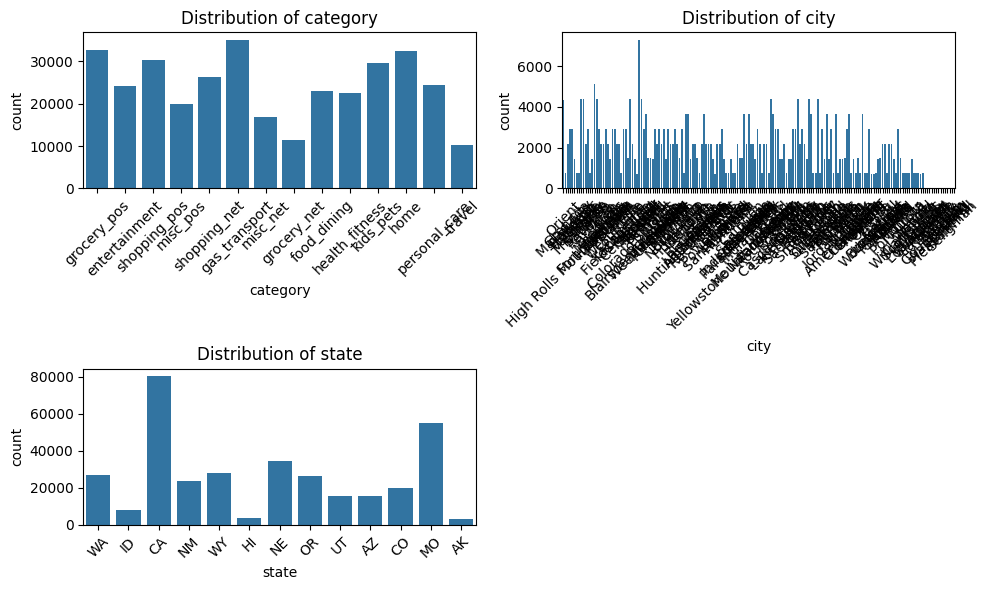

In [10]:
cat_cols = ['category', 'city', 'state']

c_features = len(cat_cols)
c_cols = 2
c_rows = (c_features + c_cols - 1) // c_cols

fig, axesc = plt.subplots(c_rows, c_cols, figsize=(10, c_rows*3))
axesc= axesc.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axesc[i]
    )
    axesc[i].set_title(f'Distribution of {col}')
    axesc[i].set_xlabel(col)
    axesc[i].set_ylabel('count')
    axesc[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axesc)):
    axesc[j].axis('off')

plt.tight_layout()
plt.show()

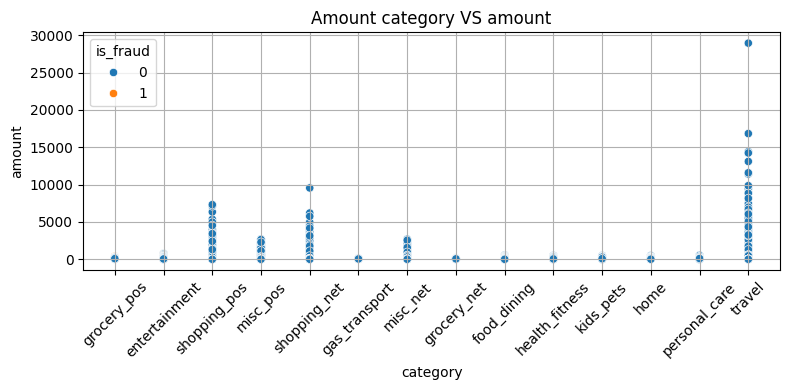

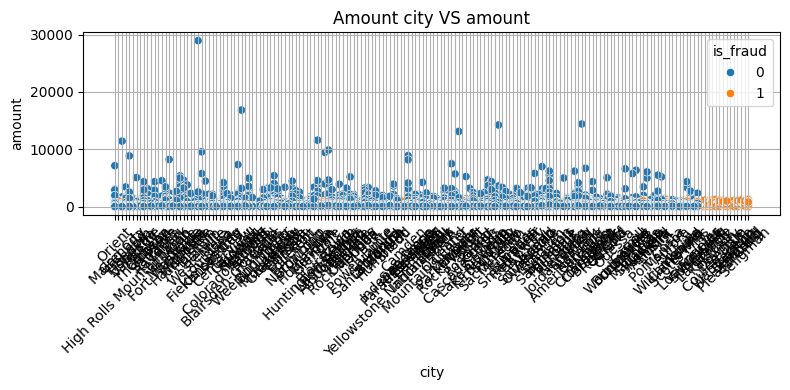

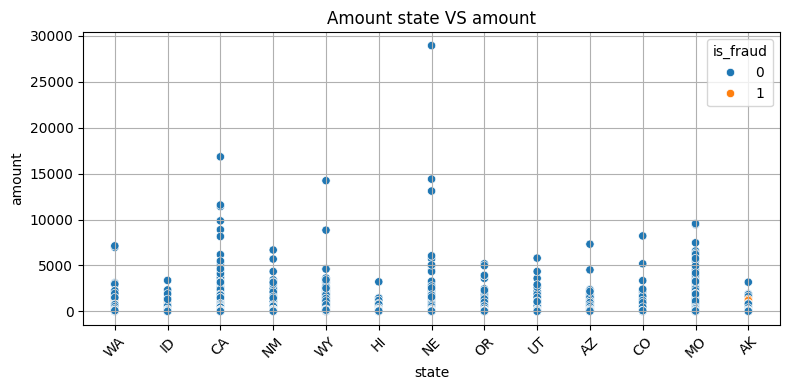

In [15]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.scatterplot(
        data=df,
        x=col,
        y='amt',
        hue='is_fraud'
        )
    plt.grid(True)
    plt.title(f'Amount {col} VS amount')
    plt.xlabel(col)
    plt.ylabel('amount')
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week']  = df['trans_date_trans_time'].dt.dayofweek
df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)
df['is_late_night'] = df['hour'].between(1, 4).astype(int)

In [5]:
df['log_amt'] = np.log1p(df['amt'])

df['amt_zscore'] = (df['amt'] - df['amt'].mean()) / df['amt'].std()

df['is_high_amt'] = (df['amt'] > df['amt'].quantile(0.95)).astype(int)

In [6]:
def haversine_distance(lat1,lon1,lat2,lon2):
  earth_radius = 6371
  lat1,lon1,lat2,lon2 = map(np.radians, [lat1,lon1,lat2,lon2])

  dlat = lat2 - lat1
  dlon = lon2 - lon1
    
  a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
  return earth_radius * 2 * np.arcsin(np.sqrt(a))

In [7]:
df['distance_from_home'] = haversine_distance(
    df['lat'],
    df['long'],
    df['merch_lat'],
    df['merch_long']
)

df['log_distance'] = np.log1p(df['distance_from_home'])

In [8]:
df['dob'] = pd.to_datetime(df['dob'],format='%Y-%m-%d')

today = pd.Timestamp('today')
df['customer_age'] = ((today - df['dob']).dt.days / 365.25).astype(int)

df['age_group'] = pd.cut(df['customer_age'], 
                          bins=[0, 25, 35, 50, 65, 100],
                          labels=['18-25', '26-35', '36-50', '51-65', '65+'])

df['age_group_encoded'] = df['age_group'].cat.codes

In [9]:
df['category'].value_counts()

category
gas_transport     35089
grocery_pos       32732
home              32516
shopping_pos      30329
kids_pets         29704
shopping_net      26379
personal_care     24406
entertainment     24222
food_dining       23038
health_fitness    22593
misc_pos          20024
misc_net          16898
grocery_net       11355
travel            10322
Name: count, dtype: int64

In [10]:
df['category_encoded'] = df.groupby('category')['is_fraud'].transform('mean')

In [11]:
df.select_dtypes(include='object').columns

Index(['merchant', 'category', 'city', 'state', 'job', 'trans_num'], dtype='object')

In [12]:
global_fraud_rate = df['is_fraud'].mean()
smoothing = 10

city_stats = df.groupby('city').agg(
    fraud_rate=('is_fraud', 'mean'),
    txn_count=('is_fraud', 'count')
).reset_index()

city_stats['city_encoded'] = (
    (city_stats['fraud_rate'] * city_stats['txn_count'] + global_fraud_rate * smoothing) /
    (city_stats['txn_count'] + smoothing)
)

city_map = city_stats.set_index('city')['city_encoded']
df['city_encoded'] = df['city'].map(city_map)
df['city_encoded'] = df['city_encoded'].fillna(global_fraud_rate)

# Same for state (simple target encoding — fewer unique values)
state_fraud_rate = df.groupby('state')['is_fraud'].mean()
df['state_encoded'] = df['state'].map(state_fraud_rate)
df['state_encoded'] = df['state_encoded'].fillna(global_fraud_rate)

print(df[['city_encoded', 'state_encoded']].describe())

        city_encoded  state_encoded
count  339607.000000  339607.000000
mean        0.005026       0.005247
std         0.012541       0.001417
min         0.000018       0.003972
25%         0.002518       0.004660
50%         0.004107       0.004994
75%         0.005470       0.005165
max         0.656982       0.016875


In [13]:
global_fraud_rate = df['is_fraud'].mean()
smoothing = 10

merchant_stats = df.groupby('merchant').agg(
    fraud_rate=('is_fraud', 'mean'),
    txn_count=('is_fraud', 'count')
).reset_index()

merchant_stats['merchant_encoded'] = (
    (merchant_stats['fraud_rate'] * merchant_stats['txn_count'] + global_fraud_rate * smoothing) /
    (merchant_stats['txn_count'] + smoothing)
)

merchant_map = merchant_stats.set_index('merchant')['merchant_encoded']
df['merchant_encoded'] = df['merchant'].map(merchant_map)
df['merchant_encoded'] = df['merchant_encoded'].fillna(global_fraud_rate)

In [14]:
job_stats = df.groupby('job').agg(
    fraud_rate=('is_fraud', 'mean'),
    txn_count=('is_fraud', 'count')
).reset_index()

job_stats['job_encoded'] = (
    (job_stats['fraud_rate'] * job_stats['txn_count'] + global_fraud_rate * smoothing) /
    (job_stats['txn_count'] + smoothing)
)

job_map = job_stats.set_index('job')['job_encoded']
df['job_encoded'] = df['job'].map(job_map)
df['job_encoded'] = df['job_encoded'].fillna(global_fraud_rate)

# Confirm
print(df[['merchant_encoded', 'job_encoded']].describe())

       merchant_encoded    job_encoded
count     339607.000000  339607.000000
mean           0.005251       0.005033
std            0.005628       0.011567
min            0.000075       0.000024
25%            0.001523       0.002745
50%            0.003310       0.004104
75%            0.007598       0.005738
max            0.033997       0.656982


In [15]:
columsn_to_drop = ['age_group', 'trans_date_trans_time', 'dob', 'category', 'city', 'state', 'trans_num', 'job', 'merchant']
df.drop(columns = columsn_to_drop, inplace=True)

In [21]:
df.sample(5)

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day_of_week,is_weekend,...,is_high_amt,distance_from_home,log_distance,customer_age,age_group_encoded,category_encoded,city_encoded,state_encoded,merchant_encoded,job_encoded
208042,71.63,38.5234,-120.6763,832,38.623554,-120.077712,0,15,4,0,...,0,53.215418,3.992965,38,2,0.002254,0.003766,0.004994,0.000104,0.003766
263171,122.34,45.8289,-118.4971,1302,45.605571,-119.327406,0,2,6,1,...,0,69.079341,4.249628,49,2,0.013229,0.003652,0.007460,0.010495,0.005186
296740,10.67,38.9999,-109.6150,46,38.283831,-110.371475,0,22,2,0,...,0,103.228787,4.646588,39,2,0.001649,0.002742,0.003972,0.002328,0.003796
35389,4.21,43.0048,-108.8964,1645,43.124531,-109.859537,0,22,0,0,...,0,79.366666,4.386599,40,2,0.001538,0.004107,0.004284,0.000079,0.004104
278891,4.10,47.2271,-117.0819,895,47.489546,-117.007663,0,21,1,0,...,0,29.713578,3.424705,26,1,0.001649,0.004117,0.004660,0.002268,0.004117


In [22]:
df.columns

Index(['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud',
       'hour', 'day_of_week', 'is_weekend', 'is_late_night', 'log_amt',
       'amt_zscore', 'is_high_amt', 'distance_from_home', 'log_distance',
       'customer_age', 'age_group_encoded', 'category_encoded', 'city_encoded',
       'state_encoded', 'merchant_encoded', 'job_encoded'],
      dtype='object')